In [3]:
import numpy as np
from scipy.optimize import minimize

In [2]:
# Example parameters for K=3 domains:
# params = [{'beta': 0.0208, 'c': 1.0462591750008245, 'gamma': 0.25288060389790434, 'alpha': 0.4818035844207287, 'e': 1.2016486537559739},
# {'beta': 0.0934, 'c': 0.13837690116529983, 'gamma': 0.00013432199135253803, 'alpha': 0.43800441184949407, 'e': 2.104247611386492},
# {'beta': 0.058, 'c': 0.9855097224514553, 'gamma': 0.056527546714503114, 'alpha': 0.467878814506637, 'e': 1.2506150895188253}]

# llama 3.2 3B
params =[
{'beta': 0.051, 'c': 1.156484125642086, 'gamma': 0.19780651007960018, 'alpha': 0.4759641653939281, 'e': 1.0964457298437293},
{'beta': 0.043, 'c': 0.7508495582040167, 'gamma': 0.040025262958907154, 'alpha': 0.43503938591132635, 'e': 1.4937431374616452},
{'beta': 0.0439, 'c': 0.9828179869932256, 'gamma': 0.1260596510875358, 'alpha': 0.46702823082847034, 'e': 1.267061465923874}
]

def objective(w, N, param_list):
    """
    Objective function to minimize:
      sum_{i=1}^K c_i * ( w_i*N + gamma_i*(N - w_i*N)^alpha_i )^(-beta_i ) + e_i
    """
    total = 0.0
    for i, p in enumerate(param_list):
        c_i = p["c"]
        gamma_i = p["gamma"]
        alpha_i = p["alpha"]
        beta_i = p["beta"]
        e_i = p["e"]

        # Expression inside parentheses
        expr = w[i] * N + gamma_i * (N - w[i] * N) ** alpha_i

        # Add term: c_i * expr^(-beta_i) + e_i
        total += c_i * (expr ** (-beta_i)) + e_i

    return total

def run(N):
    # Example: N can be any positive number relevant to your application
    # N = 10  # Adjust as needed

    K = len(params)      # Number of domains
    w0 = np.ones(K) / K  # Initial guess: equally distributed weights

    # Define bounds for each w_i in [0, 1]
    bounds = [(0, 1) for _ in range(K)]

    # Constraint: sum_{i=1 to K} w_i = 1
    cons = {
        'type': 'eq',
        'fun': lambda w: np.sum(w) - 1
    }

    # Use SLSQP to minimize the objective
    result = minimize(
        fun=objective,
        x0=w0,
        args=(N, params),
        method='SLSQP',
        bounds=bounds,
        constraints=[cons],
        options={'disp': True}  # Display solver output
    )

    if result.success:
        print("=== Optimization succeeded ===")
        print(f"Optimal weights w: {result.x}")
        print(f"Minimum objective value: {result.fun:.6f}")
    else:
        print("=== Optimization failed ===")
        print("Message:", result.message)

if __name__ == "__main__":
    for N in [5, 20, 200]:
        run(N)


Optimization terminated successfully    (Exit mode 0)
            Current function value: 6.660530038732493
            Iterations: 5
            Function evaluations: 20
            Gradient evaluations: 5
=== Optimization succeeded ===
Optimal weights w: [0.41164194 0.26835549 0.32000257]
Minimum objective value: 6.660530
Optimization terminated successfully    (Exit mode 0)
            Current function value: 6.492995202152645
            Iterations: 5
            Function evaluations: 20
            Gradient evaluations: 5
=== Optimization succeeded ===
Optimal weights w: [0.42004145 0.25726491 0.32269364]
Minimum objective value: 6.492995
Optimization terminated successfully    (Exit mode 0)
            Current function value: 6.230204402304066
            Iterations: 5
            Function evaluations: 20
            Gradient evaluations: 5
=== Optimization succeeded ===
Optimal weights w: [0.42313732 0.25127053 0.32559215]
Minimum objective value: 6.230204


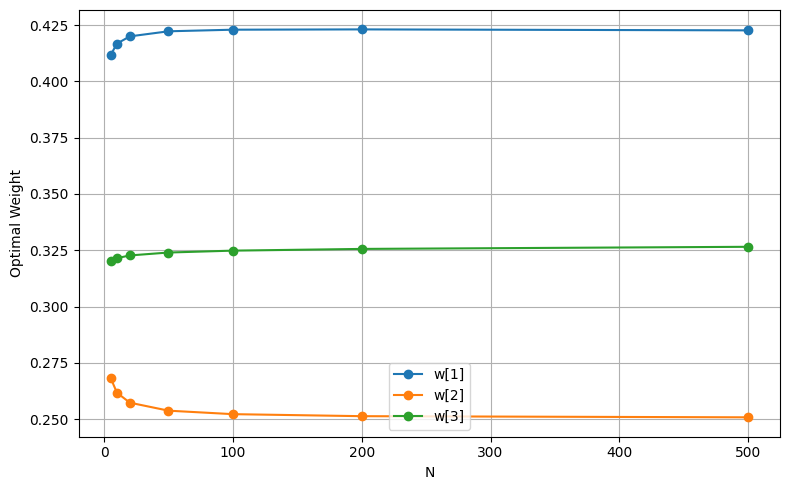

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def run(N):
    """
    This function should perform the optimization for a given N
    and return the optimal weights (e.g., result.x).

    Assumes you have code like:

    def run(N):
        # 1) Build the objective & constraints (depends on N)
        # 2) Call 'minimize(...)'
        # 3) Return result.x if success, or None/raise error otherwise
        pass
    """
    # -----------------
    # Example skeleton:
    # -----------------
    from scipy.optimize import minimize

    # Suppose you have param_list defined elsewhere or as a global
    param_list = [
{'beta': 0.051, 'c': 1.156484125642086, 'gamma': 0.19780651007960018, 'alpha': 0.4759641653939281, 'e': 1.0964457298437293},
{'beta': 0.043, 'c': 0.7508495582040167, 'gamma': 0.040025262958907154, 'alpha': 0.43503938591132635, 'e': 1.4937431374616452},
{'beta': 0.0439, 'c': 0.9828179869932256, 'gamma': 0.1260596510875358, 'alpha': 0.46702823082847034, 'e': 1.267061465923874}
    ]

    # Objective function (example)
    def objective(w):
        total = 0.0
        for i, p in enumerate(param_list):
            c_i = p["c"]
            gamma_i = p["gamma"]
            alpha_i = p["alpha"]
            beta_i = p["beta"]
            e_i = p["e"]

            expr = w[i]*N + gamma_i*(N - w[i]*N)**alpha_i
            total += c_i*(expr**(-beta_i)) + e_i
        return total

    # Number of weight variables
    K = len(param_list)
    w0 = np.ones(K) / K  # initial guess
    bounds = [(0,1)] * K

    # Equality constraint: sum of w_i = 1
    cons = {
        'type': 'eq',
        'fun': lambda w: np.sum(w) - 1
    }

    result = minimize(
        fun=objective,
        x0=w0,
        method='SLSQP',
        bounds=bounds,
        constraints=[cons],
        options={'disp': False}  # turn off solver output
    )

    if result.success:
        # Print if you want:
        # print(f"N={N}, w={result.x}, objective={result.fun:.4f}")
        return result.x
    else:
        print(f"Optimization failed for N={N}: {result.message}")
        return None

# def main():
    # Values of N to test
N_values = [5, 10, 20, 50, 100, 200, 500]

# We'll store each solution vector in a list
solutions = []

for N in N_values:
    w_opt = run(N)
    solutions.append(w_opt)

# Convert solutions to a NumPy array of shape (len(N_values), K)
solutions = np.array(solutions)  # shape: (#N_values, #domains)

# If any optimization failed (returned None), handle that
# e.g., filter them out or skip plotting. For simplicity, we assume all succeed.

# Plot each weight dimension vs. N
plt.figure(figsize=(8, 5))

# Number of weight components (K)
K = solutions.shape[1]

for i in range(K):
    # Plot w_i vs. N
    plt.plot(N_values, solutions[:, i], marker='o', label=f'w[{i+1}]')

plt.xlabel('N')
plt.ylabel('Optimal Weight')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# if __name__ == "__main__":
#     main()


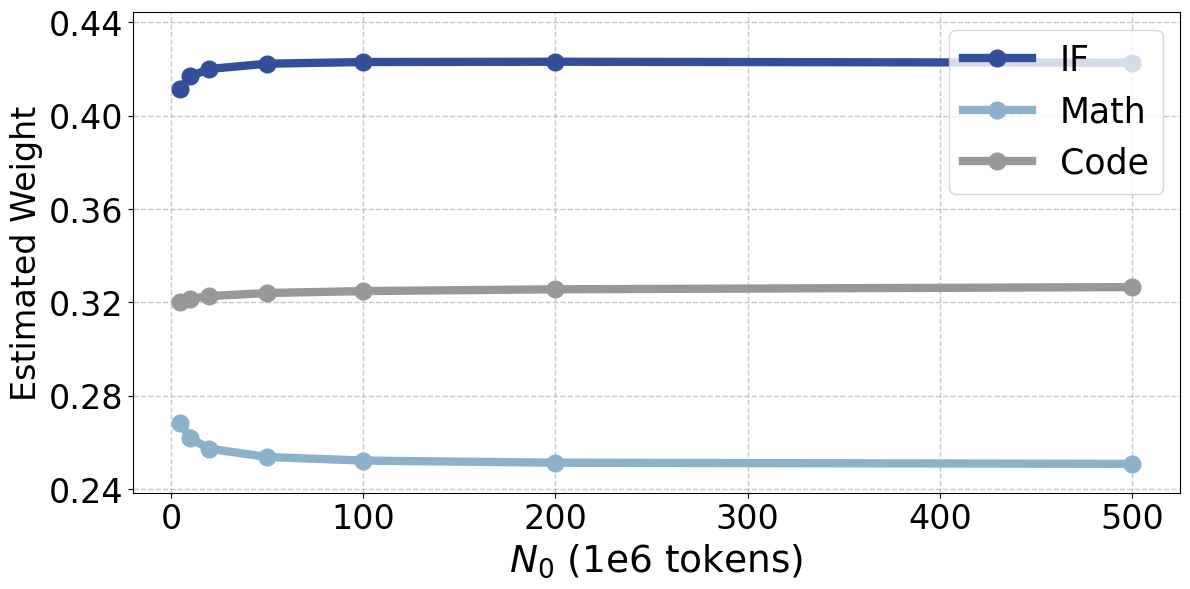

In [45]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np

# Define colors and names for each domain
DOMAIN_COLORS = ["#344F99", "#8CB1CA", "#989898"]  # Extend this list if K > len(DOMAIN_COLORS)
DOMAIN_NAMES = ["IF", "Math", "Code"]

# Ensure that DOMAIN_COLORS has enough colors
def get_color(index):
    return DOMAIN_COLORS[index % len(DOMAIN_COLORS)]

# Plot each domain's optimal weight vs. N
fig, ax = plt.subplots(figsize=(12, 6))  # Increased figsize for better readability

K = solutions.shape[1]  # Number of weight components

for i in range(K):
    color = get_color(i)  # Get color for the current domain
    ax.plot(
        N_values,
        solutions[:, i],
        marker='o',
        color=color,
        linestyle='-',
        linewidth=6,        # Adjusted for better visual balance
        markersize=12,      # Adjusted for better visual balance
        label=DOMAIN_NAMES[i]  # Correctly formatted label
    )

# Customize axis labels with larger font size and LaTeX for subscript
ax.set_xlabel(r'$N_0$ (1e6 tokens)', fontsize=27)
ax.set_ylabel('Estimated Weight', fontsize=24)

# Customize tick parameters
ax.tick_params(axis='both', which='major', labelsize=24)
ax.xaxis.set_major_locator(MaxNLocator(nbins=6))  # Limit number of x-axis ticks
ax.yaxis.set_major_locator(MaxNLocator(nbins=6))  # Limit number of y-axis ticks

y_min = np.min(solutions) * 0.95
y_max = np.max(solutions) * 1.05
ax.set_ylim(y_min, y_max)
# Add legend with larger font size and a title
ax.legend(fontsize=25)

# Enable grid with custom style
ax.grid(True, linestyle='--', linewidth=1, alpha=0.7)

# Adjust layout for better spacing
plt.tight_layout()

# Save the figure with high resolution
plt.savefig('optimal_weights.pdf', dpi=300)

# Display the plot
plt.show()


## Llama 8B

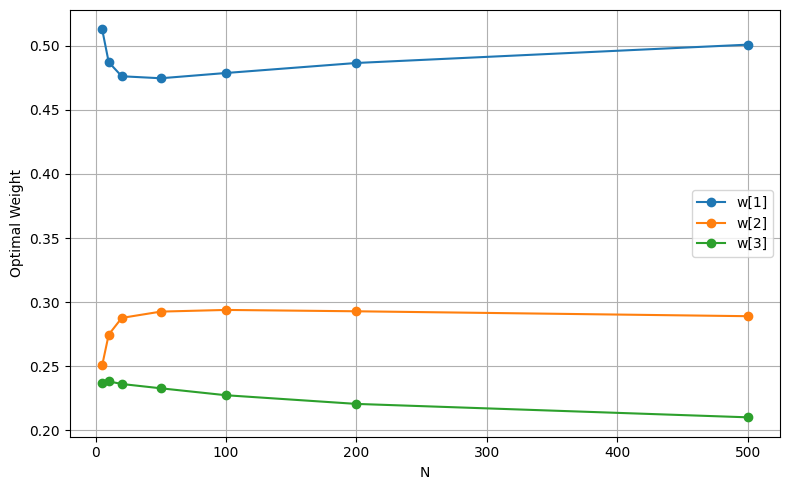

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def run(N):
    """
    This function should perform the optimization for a given N
    and return the optimal weights (e.g., result.x).

    Assumes you have code like:

    def run(N):
        # 1) Build the objective & constraints (depends on N)
        # 2) Call 'minimize(...)'
        # 3) Return result.x if success, or None/raise error otherwise
        pass
    """
    # -----------------
    # Example skeleton:
    # -----------------
    from scipy.optimize import minimize

    # Suppose you have param_list defined elsewhere or as a global
    param_list = [
{'beta': 0.1074,
  'c': 0.9303720966305796,
  'gamma': 0.8353839985461634,
  'alpha': 0.5601292648858495,
  'e': 1.4226529933436454},
 {'beta': 0.2056,
  'c': 0.47001708560647254,
  'gamma': 1.1442480438863765,
  'alpha': 0.5074276704841271,
  'e': 1.8919117116032493},
 {'beta': 0.2791,
  'c': 0.36073465526930765,
  'gamma': 1.106071287791263,
  'alpha': 0.5113088104398635,
  'e': 1.9937865053832902}
    ]

    # Objective function (example)
    def objective(w):
        total = 0.0
        for i, p in enumerate(param_list):
            c_i = p["c"]
            gamma_i = p["gamma"]
            alpha_i = p["alpha"]
            beta_i = p["beta"]
            e_i = p["e"]

            expr = w[i]*N + gamma_i*(N - w[i]*N)**alpha_i
            total += c_i*(expr**(-beta_i)) + e_i
        return total

    # Number of weight variables
    K = len(param_list)
    w0 = np.ones(K) / K  # initial guess
    bounds = [(0,1)] * K

    # Equality constraint: sum of w_i = 1
    cons = {
        'type': 'eq',
        'fun': lambda w: np.sum(w) - 1
    }

    result = minimize(
        fun=objective,
        x0=w0,
        method='SLSQP',
        bounds=bounds,
        constraints=[cons],
        options={'disp': False}  # turn off solver output
    )

    if result.success:
        # Print if you want:
        # print(f"N={N}, w={result.x}, objective={result.fun:.4f}")
        return result.x
    else:
        print(f"Optimization failed for N={N}: {result.message}")
        return None

# def main():
    # Values of N to test
N_values = [5, 10, 20, 50, 100, 200, 500]

# We'll store each solution vector in a list
solutions = []

for N in N_values:
    w_opt = run(N)
    solutions.append(w_opt)

# Convert solutions to a NumPy array of shape (len(N_values), K)
solutions = np.array(solutions)  # shape: (#N_values, #domains)

# If any optimization failed (returned None), handle that
# e.g., filter them out or skip plotting. For simplicity, we assume all succeed.

# Plot each weight dimension vs. N
plt.figure(figsize=(8, 5))

# Number of weight components (K)
K = solutions.shape[1]

for i in range(K):
    # Plot w_i vs. N
    plt.plot(N_values, solutions[:, i], marker='o', label=f'w[{i+1}]')

plt.xlabel('N')
plt.ylabel('Optimal Weight')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
params =[
{'beta': 0.1074,
  'c': 0.9303720966305796,
  'gamma': 0.8353839985461634,
  'alpha': 0.5601292648858495,
  'e': 1.4226529933436454},
 {'beta': 0.2056,
  'c': 0.47001708560647254,
  'gamma': 1.1442480438863765,
  'alpha': 0.5074276704841271,
  'e': 1.8919117116032493},
 {'beta': 0.2791,
  'c': 0.36073465526930765,
  'gamma': 1.106071287791263,
  'alpha': 0.5113088104398635,
  'e': 1.9937865053832902}
]

def objective(w, N, param_list):
    """
    Objective function to minimize:
      sum_{i=1}^K c_i * ( w_i*N + gamma_i*(N - w_i*N)^alpha_i )^(-beta_i ) + e_i
    """
    total = 0.0
    for i, p in enumerate(param_list):
        c_i = p["c"]
        gamma_i = p["gamma"]
        alpha_i = p["alpha"]
        beta_i = p["beta"]
        e_i = p["e"]

        # Expression inside parentheses
        expr = w[i] * N + gamma_i * (N - w[i] * N) ** alpha_i

        # Add term: c_i * expr^(-beta_i) + e_i
        total += c_i * (expr ** (-beta_i)) + e_i

    return total

def run(N):
    # Example: N can be any positive number relevant to your application
    # N = 10  # Adjust as needed

    K = len(params)      # Number of domains
    w0 = np.ones(K) / K  # Initial guess: equally distributed weights

    # Define bounds for each w_i in [0, 1]
    bounds = [(0, 1) for _ in range(K)]

    # Constraint: sum_{i=1 to K} w_i = 1
    cons = {
        'type': 'eq',
        'fun': lambda w: np.sum(w) - 1
    }

    # Use SLSQP to minimize the objective
    result = minimize(
        fun=objective,
        x0=w0,
        args=(N, params),
        method='SLSQP',
        bounds=bounds,
        constraints=[cons],
        options={'disp': True}  # Display solver output
    )

    if result.success:
        print("=== Optimization succeeded ===")
        print(f"Optimal weights w: {result.x}")
        print(f"Minimum objective value: {result.fun:.6f}")
    else:
        print("=== Optimization failed ===")
        print("Message:", result.message)

if __name__ == "__main__":
    for N in [5, 20, 200]:
        run(N)

Optimization terminated successfully    (Exit mode 0)
            Current function value: 6.731690151669496
            Iterations: 5
            Function evaluations: 20
            Gradient evaluations: 5
=== Optimization succeeded ===
Optimal weights w: [0.51288044 0.25065322 0.23646634]
Minimum objective value: 6.731690
Optimization terminated successfully    (Exit mode 0)
            Current function value: 6.502948641189349
            Iterations: 4
            Function evaluations: 16
            Gradient evaluations: 4
=== Optimization succeeded ===
Optimal weights w: [0.47629393 0.28764629 0.23605978]
Minimum objective value: 6.502949
Optimization terminated successfully    (Exit mode 0)
            Current function value: 6.181214692251749
            Iterations: 6
            Function evaluations: 24
            Gradient evaluations: 6
=== Optimization succeeded ===
Optimal weights w: [0.48666725 0.29281993 0.22051281]
Minimum objective value: 6.181215
